In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import shutil
import random
import hashlib
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print("All imports OK")

All imports OK


In [3]:
BASE_DIR   = "/kaggle/input/datasets/illickalkunnu/finalproject/kitti1"
IMAGES_DIR = f"{BASE_DIR}/images"
LABELS_DIR = f"{BASE_DIR}/labels"

print(f"Images : {IMAGES_DIR}")
print(f"Labels : {LABELS_DIR}")
print(f"Images found : {len(os.listdir(IMAGES_DIR))}")
print(f"Labels found : {len(os.listdir(LABELS_DIR))}")

Images : /kaggle/input/datasets/illickalkunnu/finalproject/kitti1/images
Labels : /kaggle/input/datasets/illickalkunnu/finalproject/kitti1/labels
Images found : 7481
Labels found : 7481


In [4]:
NUM_CLASSES = 8
valid_imgs, valid_lbls = set(), set()
errors = []

for lbl_file in os.listdir(LABELS_DIR):
    if not lbl_file.endswith(".txt"):
        continue
    lbl_path = os.path.join(LABELS_DIR, lbl_file)
    stem     = os.path.splitext(lbl_file)[0]

    matched = None
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGES_DIR, stem + ext)):
            matched = stem + ext
            break
    if not matched:
        errors.append(f"No image for label: {lbl_file}")
        continue

    with open(lbl_path) as f:
        lines = f.readlines()
    if not lines:
        errors.append(f"Empty label file: {lbl_file}")
        continue

    valid = True
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) != 5:
            errors.append(f"{lbl_file} line {i+1}: expected 5 values, got {len(parts)}")
            valid = False
            continue
        cls    = int(parts[0])
        coords = list(map(float, parts[1:]))
        if not (0 <= cls < NUM_CLASSES):
            errors.append(f"{lbl_file} line {i+1}: invalid class {cls}")
            valid = False
        if not all(0.0 <= c <= 1.0 for c in coords):
            errors.append(f"{lbl_file} line {i+1}: coords out of range")
            valid = False

    if valid:
        valid_imgs.add(matched)
        valid_lbls.add(lbl_file)

print(f"Valid pairs: {len(valid_lbls)}")
if errors:
    print(f"Errors found ({len(errors)}):")
    for e in errors[:10]:
        print(f"  {e}")
else:
    print("No errors!")

Valid pairs: 7481
No errors!


In [5]:
src_labels = LABELS_DIR
src_images = IMAGES_DIR
dst_labels = "/kaggle/working/clean/labels"
dst_images = "/kaggle/working/clean/images"

os.makedirs(dst_labels, exist_ok=True)
os.makedirs(dst_images, exist_ok=True)

kept = 0
removed = 0

for label_file in os.listdir(src_labels):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(src_labels, label_file)
    keep = True

    if os.path.getsize(label_path) == 0:
        keep = False
    else:
        with open(label_path, "r") as f:
            for line in f:
                if len(line.strip().split()) != 5:
                    keep = False
                    break

    base = os.path.splitext(label_file)[0]
    img_path = None
    for ext in [".jpg", ".png", ".jpeg"]:
        temp = os.path.join(src_images, base + ext)
        if os.path.exists(temp):
            img_path = temp
            break

    if keep and img_path:
        shutil.copy(label_path, os.path.join(dst_labels, label_file))
        shutil.copy(img_path, os.path.join(dst_images, os.path.basename(img_path)))
        kept += 1
    else:
        removed += 1

print(f"Kept: {kept}, Removed: {removed}")

Kept: 7481, Removed: 0


In [6]:
IMAGES_DIR_CLEAN = "/kaggle/working/clean/images"
LABELS_DIR_CLEAN = "/kaggle/working/clean/labels"
BLUR_THRESHOLD   = 320.0

blurry, sharp = [], []
deleted = 0

for fname in tqdm(os.listdir(IMAGES_DIR_CLEAN), desc="Blur check"):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(IMAGES_DIR_CLEAN, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()

    if variance < BLUR_THRESHOLD:
        blurry.append(fname)
        os.remove(img_path)
        stem = os.path.splitext(fname)[0]
        lbl = os.path.join(LABELS_DIR_CLEAN, stem + ".txt")
        if os.path.exists(lbl):
            os.remove(lbl)
        deleted += 1
    else:
        sharp.append(fname)

print(f"Sharp: {len(sharp)}, Blurry/deleted: {len(blurry)}")

Blur check: 100%|██████████| 7481/7481 [00:56<00:00, 133.29it/s]

Sharp: 7301, Blurry/deleted: 180


In [7]:
IMAGES_DIR_CLEAN = "/kaggle/working/clean/images"
SKIP_LIST_PATH   = "/kaggle/working/duplicates_to_skip.txt"

def phash(img, hash_size=8):
    resized = cv2.resize(img, (hash_size + 1, hash_size))
    gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    return (gray[:, 1:] > gray[:, :-1]).flatten()

def hamming(h1, h2):
    return int((h1 != h2).sum())

def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

duplicates_to_skip = set()

print("Pass 1: Exact duplicates (MD5)...")
md5_map = defaultdict(list)
for fname in os.listdir(IMAGES_DIR_CLEAN):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    md5_map[md5(os.path.join(IMAGES_DIR_CLEAN, fname))].append(fname)
for files in md5_map.values():
    if len(files) > 1:
        for dup in files[1:]:
            duplicates_to_skip.add(dup)
print(f"  Exact duplicates: {len(duplicates_to_skip)}")

print("Pass 2: Near-duplicates (pHash)...")
images = []
for fname in os.listdir(IMAGES_DIR_CLEAN):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')) or fname in duplicates_to_skip:
        continue
    img = cv2.imread(os.path.join(IMAGES_DIR_CLEAN, fname))
    if img is not None:
        images.append((fname, phash(img)))

PHASH_THRESH = 8
near_dup = 0
for i in tqdm(range(len(images)), desc="pHash compare"):
    if images[i][0] in duplicates_to_skip:
        continue
    for j in range(i + 1, len(images)):
        if images[j][0] not in duplicates_to_skip:
            if hamming(images[i][1], images[j][1]) <= PHASH_THRESH:
                duplicates_to_skip.add(images[j][0])
                near_dup += 1
print(f"  Near-duplicates: {near_dup}")

with open(SKIP_LIST_PATH, "w") as f:
    for fname in sorted(duplicates_to_skip):
        f.write(fname + "\n")

remaining = len([f for f in os.listdir(IMAGES_DIR_CLEAN)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                 and f not in duplicates_to_skip])
print(f"Total to skip: {len(duplicates_to_skip)}, Clean remaining: {remaining}")

Pass 1: Exact duplicates (MD5)...
  Exact duplicates: 0
Pass 2: Near-duplicates (pHash)...


pHash compare: 100%|██████████| 7301/7301 [00:54<00:00, 132.93it/s] 

  Near-duplicates: 1097
Total to skip: 1097, Clean remaining: 6204


Raw class distribution:
  Car                  (class 0):  27809
  Van                  (class 1):   2750
  Truck                (class 2):   1036
  Pedestrian           (class 3):   4474
  Person_sitting       (class 4):    222
  Cyclist              (class 5):   1621
  Tram                 (class 6):    511
  Misc                 (class 7):    835


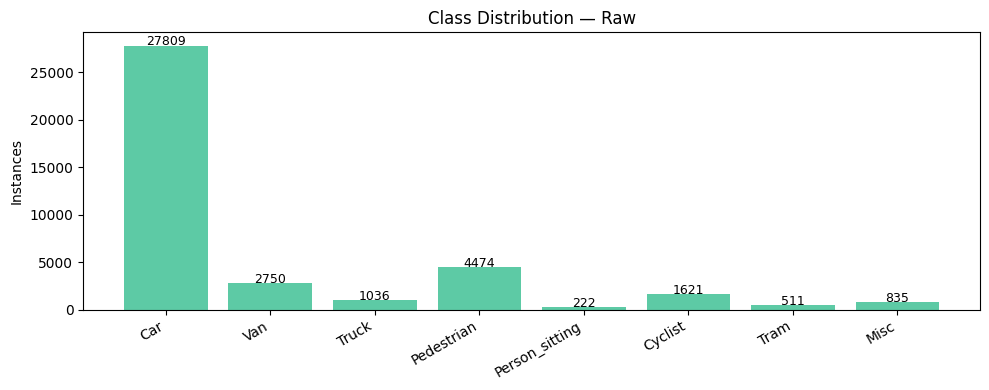

In [8]:
LABELS_DIR_CLEAN = "/kaggle/working/clean/labels"
CLASS_NAMES_RAW  = ["Car","Van","Truck","Pedestrian","Person_sitting","Cyclist","Tram","Misc"]

class_counts = defaultdict(int)
for lbl_file in os.listdir(LABELS_DIR_CLEAN):
    if not lbl_file.endswith(".txt"):
        continue
    with open(os.path.join(LABELS_DIR_CLEAN, lbl_file)) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

print("Raw class distribution:")
for i, name in enumerate(CLASS_NAMES_RAW):
    count = class_counts.get(i, 0)
    print(f"  {name:20s} (class {i}): {count:6d}")

labels = [CLASS_NAMES_RAW[i] for i in sorted(class_counts)]
values = [class_counts[i] for i in sorted(class_counts)]
plt.figure(figsize=(10, 4))
bars = plt.bar(labels, values, color="#5DCAA5")
plt.title("Class Distribution — Raw")
plt.ylabel("Instances")
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution_raw.png")
plt.show()

In [9]:
LABELS_DIR_CLEAN = "/kaggle/working/clean/labels"
LBL_DIR_OUT      = "/kaggle/working/labels_final"
os.makedirs(LBL_DIR_OUT, exist_ok=True)

MERGE_MAP = {
    0: 0, 1: 0, 2: 0,     # Car, Van, Truck → Car
    3: 1, 4: 1,            # Pedestrian, Person_sitting → Pedestrian
    5: 2,                  # Cyclist → Cyclist
    6: -1, 7: -1, 8: -1   # Tram, Misc, DontCare → drop
}
ORIG_NAMES  = ["Car","Van","Truck","Pedestrian","Person_sitting","Cyclist","Tram","Misc","DontCare"]
CLASS_NAMES = ["Car","Pedestrian","Cyclist"]

clipped = 0
merge_stats   = defaultdict(int)
dropped_stats = defaultdict(int)

for lbl_name in os.listdir(LABELS_DIR_CLEAN):
    if not lbl_name.endswith(".txt"):
        continue
    new_lines = []
    with open(os.path.join(LABELS_DIR_CLEAN, lbl_name)) as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        old_cls = int(float(parts[0]))
        new_cls = MERGE_MAP.get(old_cls, -1)
        if new_cls == -1:
            dropped_stats[old_cls] += 1
            continue

        # Clip bounding box to [0, 1]
        xc, yc, bw, bh = map(float, parts[1:])
        x1 = max(0.0, xc - bw / 2)
        y1 = max(0.0, yc - bh / 2)
        x2 = min(1.0, xc + bw / 2)
        y2 = min(1.0, yc + bh / 2)
        new_bw = x2 - x1
        new_bh = y2 - y1
        new_xc = x1 + new_bw / 2
        new_yc = y1 + new_bh / 2

        if (new_bw, new_bh) != (bw, bh):
            clipped += 1

        # Discard tiny/zero-area boxes
        if new_bw * new_bh < 0.0001 or new_bw <= 0 or new_bh <= 0:
            continue

        merge_stats[f"{old_cls}→{new_cls}"] += 1
        new_lines.append(f"{new_cls} {new_xc:.6f} {new_yc:.6f} {new_bw:.6f} {new_bh:.6f}\n")

    if new_lines:
        with open(os.path.join(LBL_DIR_OUT, lbl_name), "w") as f:
            f.writelines(new_lines)
    # If no lines remain after dropping, skip (don't write empty file)

print(f"Boxes clipped: {clipped}")
print("\nKept & remapped:")
for mapping, count in sorted(merge_stats.items()):
    old_id, new_id = map(int, mapping.split("→"))
    print(f"  {ORIG_NAMES[old_id]:<20} → {CLASS_NAMES[new_id]:<15}: {count:,}")
print("\nDropped:")
for old_id, count in sorted(dropped_stats.items()):
    print(f"  {ORIG_NAMES[old_id]:<20} → dropped: {count:,}")

Boxes clipped: 36857

Kept & remapped:
  Car                  → Car            : 27,807
  Van                  → Car            : 2,750
  Truck                → Car            : 1,036
  Pedestrian           → Pedestrian     : 4,473
  Person_sitting       → Pedestrian     : 222
  Cyclist              → Cyclist        : 1,621

Dropped:
  Tram                 → dropped: 511
  Misc                 → dropped: 835


In [10]:
class_counts = defaultdict(int)
for lbl_name in os.listdir(LBL_DIR_OUT):
    if not lbl_name.endswith(".txt"):
        continue
    with open(os.path.join(LBL_DIR_OUT, lbl_name)) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_counts[int(float(parts[0]))] += 1

total = sum(class_counts.values())
print("Distribution after merge:")
for cls_id, name in enumerate(CLASS_NAMES):
    c = class_counts[cls_id]
    print(f"  {name:<15}: {c:>8,} ({100*c/total:.1f}%)")
ratio = max(class_counts.values()) / max(min(class_counts.values()), 1)
print(f"\nImbalance ratio: {ratio:.1f}x")

Distribution after merge:
  Car            :   31,593 (83.3%)
  Pedestrian     :    4,695 (12.4%)
  Cyclist        :    1,621 (4.3%)

Imbalance ratio: 19.5x


In [11]:
IMG_DIR    = "/kaggle/working/clean/images"
LBL_DIR    = "/kaggle/working/labels_final"
OUTPUT_DIR = "/kaggle/working/dataset_split"
SEED       = 42

SKIP_LIST_PATH = "/kaggle/working/duplicates_to_skip.txt"
skip_list      = set()
if os.path.exists(SKIP_LIST_PATH):
    with open(SKIP_LIST_PATH) as f:
        skip_list = {line.strip() for line in f}

stems = []
for lbl_name in os.listdir(LBL_DIR):
    if not lbl_name.endswith(".txt"):
        continue
    stem = os.path.splitext(lbl_name)[0]
    if stem + ".png" in skip_list or stem + ".jpg" in skip_list or stem + ".jpeg" in skip_list:
        continue
    img_found = None
    for ext in [".png", ".jpg", ".jpeg"]:
        if os.path.exists(os.path.join(IMG_DIR, stem + ext)):
            img_found = stem + ext
            break
    if not img_found:
        continue
    with open(os.path.join(LBL_DIR, lbl_name)) as f:
        if any(l.strip() for l in f):
            stems.append(stem)

print(f"Total valid samples: {len(stems)}")

train_val, test = train_test_split(stems, test_size=0.10, random_state=SEED)
train, val      = train_test_split(train_val, test_size=0.10/0.90, random_state=SEED)
print(f"Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}")

for split, split_stems in [("train", train), ("val", val), ("test", test)]:
    img_out = os.path.join(OUTPUT_DIR, split, "images")
    lbl_out = os.path.join(OUTPUT_DIR, split, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for stem in split_stems:
        for ext in [".png", ".jpg", ".jpeg"]:
            src_img = os.path.join(IMG_DIR, stem + ext)
            if os.path.exists(src_img):
                shutil.copy2(src_img, os.path.join(img_out, stem + ext))
                break
        src_lbl = os.path.join(LBL_DIR, stem + ".txt")
        if os.path.exists(src_lbl):
            shutil.copy2(src_lbl, os.path.join(lbl_out, stem + ".txt"))
    print(f"  {split:5s}: {len(split_stems):,} pairs copied")
print("Dataset split complete.")

Total valid samples: 6204
Train: 4,962  Val: 621  Test: 621
  train: 4,962 pairs copied
  val  : 621 pairs copied
  test : 621 pairs copied
Dataset split complete.


In [12]:
for split in ["train", "val", "test"]:
    LBL_D = f"/kaggle/working/dataset_split/{split}/labels"
    cc = defaultdict(int)
    for lbl_name in os.listdir(LBL_D):
        if not lbl_name.endswith(".txt"):
            continue
        with open(os.path.join(LBL_D, lbl_name)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cc[int(float(parts[0]))] += 1
    print(f"[{split.upper()}]")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name:<15}: {cc.get(i, 0):>8,}")

[TRAIN]
  Car            :   23,221
  Pedestrian     :    2,960
  Cyclist        :    1,141
[VAL]
  Car            :    2,961
  Pedestrian     :      431
  Cyclist        :      148
[TEST]
  Car            :    2,850
  Pedestrian     :      391
  Cyclist        :      170


In [13]:
with open("/kaggle/working/data.yaml", "w") as f:
    f.write("""path: /kaggle/working/dataset_split

train: train/images
val:   val/images
test:  test/images

nc: 3
names: ["Car", "Pedestrian", "Cyclist"]
""")
print("data.yaml written.")
print(open("/kaggle/working/data.yaml").read())

data.yaml written.
path: /kaggle/working/dataset_split

train: train/images
val:   val/images
test:  test/images

nc: 3
names: ["Car", "Pedestrian", "Cyclist"]



In [14]:
import subprocess
subprocess.run(["pip", "install", "-q", "ultralytics"], check=True)
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.37


In [15]:
from collections import Counter

TRAIN_LBL = "/kaggle/working/dataset_split/train/labels"
cc = Counter()
for fname in os.listdir(TRAIN_LBL):
    if fname.endswith(".txt"):
        with open(os.path.join(TRAIN_LBL, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cc[int(parts[0])] += 1

print("Train class counts:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {cc[i]:,}")

# cls_pw = max_count / count_i  (weight up minority classes)
max_count = max(cc.values())
cls_pw = [round(max_count / max(cc[i], 1), 2) for i in range(3)]
print(f"\ncls_pw = {cls_pw}  (Car, Pedestrian, Cyclist)")
print("These will be passed to model.train() — no image duplication needed.")

Train class counts:
  Car: 23,221
  Pedestrian: 2,960
  Cyclist: 1,141

cls_pw = [1.0, 7.84, 20.35]  (Car, Pedestrian, Cyclist)
These will be passed to model.train() — no image duplication needed.


In [16]:
import os
import torch
from ultralytics import YOLO
from collections import Counter

model = YOLO("yolov8m.pt")

# Compute class weights
TRAIN_LBL = "/kaggle/working/dataset_split/train/labels"
cc = Counter()

for fname in os.listdir(TRAIN_LBL):
    if fname.endswith(".txt"):
        with open(os.path.join(TRAIN_LBL, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cc[int(parts[0])] += 1

max_count = max(cc.values())
cls_pw = [round(max_count / max(cc[i], 1), 2) for i in range(3)]
print(f"Using cls_pw: {cls_pw}")

results = model.train(
    data    = "/kaggle/working/data.yaml",
    epochs  = 50,
    imgsz   = 1280,
    batch   = 4,
    device  = 0 if torch.cuda.is_available() else "cpu",

    # Optimizer
    optimizer    = "SGD",
    lr0          = 0.01,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    overlap_mask = False,
    conf         = 0.2,

    # LR scheduling
    cos_lr        = True,
    warmup_epochs = 3,

    # Augmentation
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 5.0,
    translate    = 0.1,
    scale        = 0.5,
    shear        = 2.0,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    copy_paste   = 0.3,
    auto_augment = "augmix",
    close_mosaic = 15,

    # Loss weights
    box = 7.5,
    cls = 0.5,
    dfl = 1.5,

    # Logging & stability
    patience = 25,
    workers  = 4,
    verbose  = True,
    plots    = True,

    # 🔥 IMPORTANT (Checkpointing)
    save        = True,
    save_period = 5,   # save every epoch
    project     = "/kaggle/working/runs",
    name        = "train_yolo",
    exist_ok    = True
)

print("\nTraining complete!")
print("Best weights saved at:")
print("/kaggle/working/runs/train_yolo/weights/best.pt")

Using cls_pw: [1.0, 7.84, 20.35]
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=augmix, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=0.2, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_ma

In [17]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/train_yolo/weights/best.pt")

metrics = model.val(
    data  = "/kaggle/working/data.yaml",
    split = "test",
    imgsz = 1280,   # must match training imgsz
    rect  = True,
)

CLASS_NAMES = ["Car", "Pedestrian", "Cyclist"]

print("\n===== Test Set Results =====")
print(f"Precision  (mean): {metrics.box.mp:.4f}")
print(f"Recall     (mean): {metrics.box.mr:.4f}")
print(f"mAP50      (mean): {metrics.box.map50:.4f}")
print(f"mAP50-95   (mean): {metrics.box.map:.4f}")

print("\n📊 Per-Class mAP50-95:")
for name, ap in zip(CLASS_NAMES, metrics.box.maps):
    print(f"  {name:<15}: {ap:.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1207.0±303.7 MB/s, size: 50.5 KB)
val: Scanning /kaggle/working/dataset_split/test/labels... 621 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 621/621 1.3Kit/s 0.5s<0.1s
val: New cache created: /kaggle/working/dataset_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.6it/s 23.8s0.6ss
                   all        621       3411      0.923      0.849      0.924       0.68
                   Car        594       2850      0.957      0.961      0.986      0.855
            Pedestrian        127        391       0.89      0.716      0.855      0.505
               Cyclist        105        170      0.921      0.871       0.93      0.679
Speed: 1.4ms preprocess, 33.2ms inference, 0.0ms

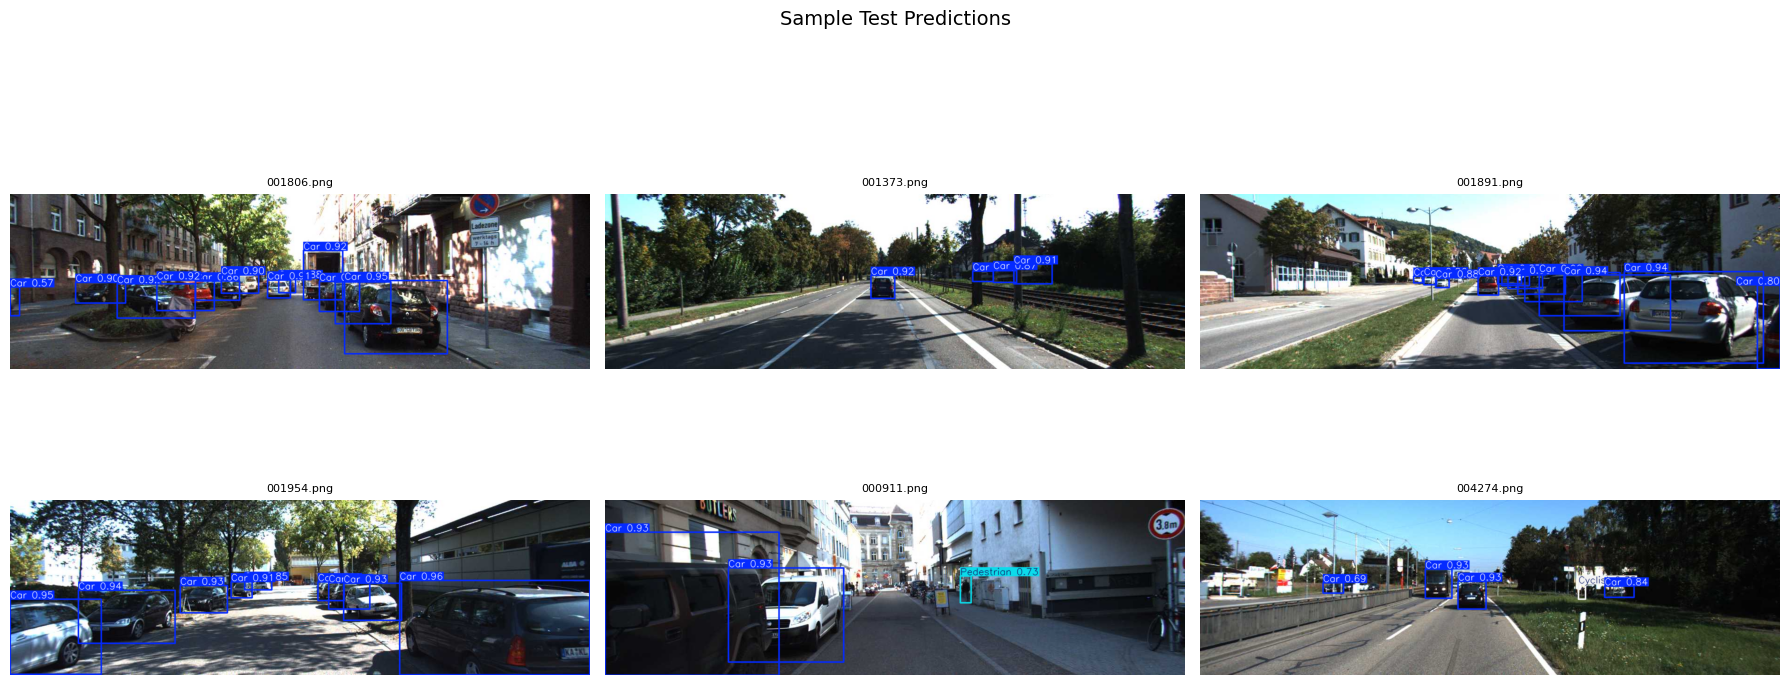

In [18]:
from ultralytics import YOLO

model    = YOLO("/kaggle/working/runs/train_yolo/weights/best.pt")
TEST_IMG = "/kaggle/working/dataset_split/test/images"

test_imgs = [f for f in os.listdir(TEST_IMG) if f.endswith(('.jpg', '.png', '.jpeg'))]
samples   = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, fname in zip(axes.flatten(), samples):
    img_path = os.path.join(TEST_IMG, fname)
    result   = model(img_path, imgsz=1280, conf=0.25, iou=0.45, verbose=False)[0]
    img_ann  = result.plot()
    ax.imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Test Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

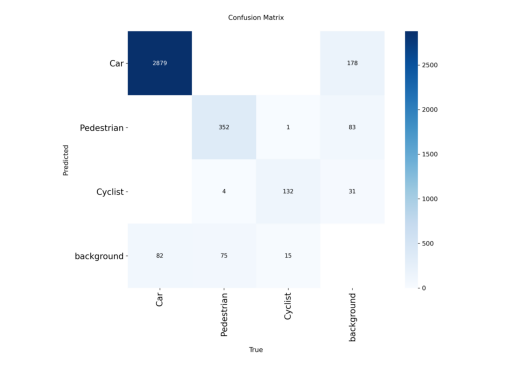

In [19]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/train_yolo/confusion_matrix.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/train_yolo/weights/best.pt")

metrics = model.val(data="/kaggle/working/data.yaml", split="test")  # or "test"

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1161.2±299.3 MB/s, size: 51.0 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 621 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 621/621 217.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.6it/s 24.1s0.6ss
                   all        621       3411      0.923      0.849      0.924       0.68
                   Car        594       2850      0.957      0.961      0.986      0.855
            Pedestrian        127        391       0.89      0.716      0.855      0.505
               Cyclist        105        170      0.921      0.871       0.93      0.679
Speed: 1.5ms preprocess, 33.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/r

In [21]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/train_yolo/weights/best.pt")

metrics = model.val(
    data="/kaggle/working/data.yaml",
    split="test",      # 🔥 IMPORTANT (use test set)
    plots=True         # 🔥 enables confusion matrix & curves
)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1232.1±426.8 MB/s, size: 49.4 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 621 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 621/621 217.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.7it/s 22.4s0.6ss
                   all        621       3411      0.923      0.849      0.924       0.68
                   Car        594       2850      0.957      0.961      0.986      0.855
            Pedestrian        127        391       0.89      0.716      0.855      0.505
               Cyclist        105        170      0.921      0.871       0.93      0.679
Speed: 1.3ms preprocess, 30.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/r

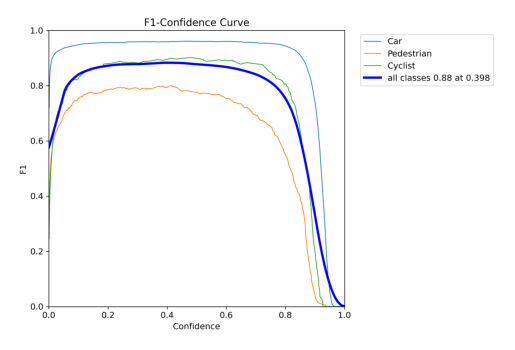

In [22]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/detect/val3/BoxF1_curve.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

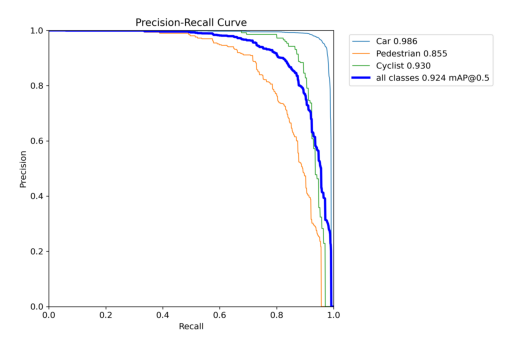

In [23]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/detect/val3/BoxPR_curve.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

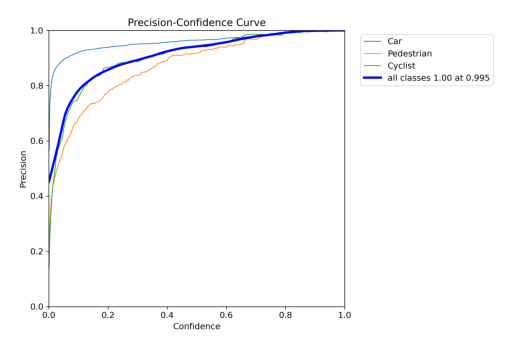

In [24]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/detect/val3/BoxP_curve.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

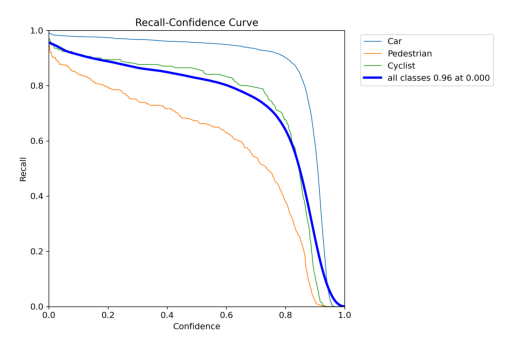

In [25]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/detect/val3/BoxR_curve.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

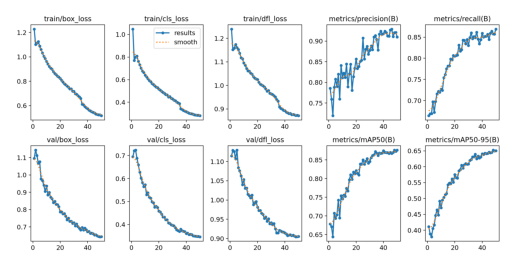

In [26]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/train_yolo/results.png"  # change path

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.show()

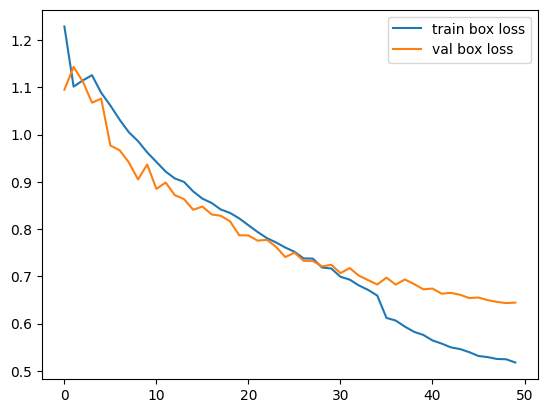

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runs/train_yolo/results.csv")

plt.plot(df['train/box_loss'], label='train box loss')
plt.plot(df['val/box_loss'], label='val box loss')
plt.legend()
plt.show()

In [28]:
import pandas as pd
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

test_map50_list = []

for epoch in range(1, 51):
    model.train(
        data="/kaggle/working/data.yaml",
        epochs=1,
        imgsz=1280,
        batch=4,
        device=0,
        resume=True
    )

    # Evaluate on TEST after each epoch
    metrics = model.val(
        data="/kaggle/working/data.yaml",
        split="test",
        verbose=False
    )

    test_map50_list.append(metrics.box.map50)

# Save test results
pd.DataFrame({"test_map50": test_map50_list}).to_csv("test_map50.csv", index=False)

WARNING ⚠️ model 'yolov8m.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

KeyError: 'model'

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1139.3±249.9 MB/s, size: 59.4 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 621 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 621/621 186.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.6it/s 23.8s0.6ss
                   all        621       3411      0.923      0.849      0.924       0.68
                   Car        594       2850      0.957      0.961      0.986      0.855
            Pedestrian        127        391       0.89      0.716      0.855      0.505
               Cyclist        105        170      0.921      0.871       0.93      0.679
Speed: 1.4ms preprocess, 33.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/r

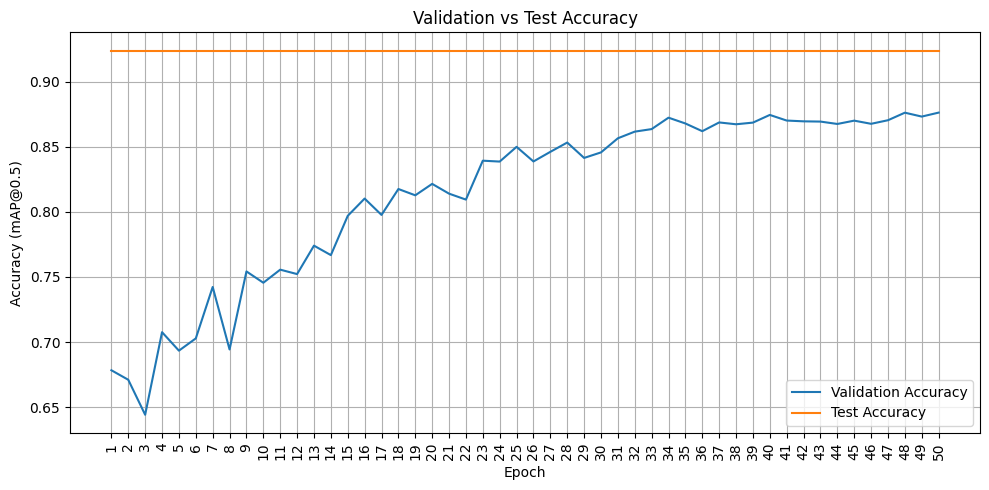

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load training results (per epoch validation metrics)
df = pd.read_csv("/kaggle/working/runs/train_yolo/results.csv")

# Validation accuracy per epoch
val_map50 = df["metrics/mAP50(B)"]

# Load best model for test evaluation
model = YOLO("/kaggle/working/runs/train_yolo/weights/best.pt")
test_metrics = model.val(data="data.yaml", split="test")

# Constant test accuracy line
test_map50 = test_metrics.box.map50
test_line = [test_map50] * len(val_map50)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], val_map50, label="Validation Accuracy")
plt.plot(df["epoch"], test_line, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (mAP@0.5)")
plt.title("Validation vs Test Accuracy")

plt.legend()
plt.grid(True)

# Match your dense x-axis style
plt.xticks(df["epoch"], rotation=90)

plt.tight_layout()
plt.show()